In [2]:
from torchgpe.bec2D import Gas
from torchgpe.bec2D.potentials import Contact, Trap

import torch

bec = Gas(N_particles=2e5, grid_size=3e-5)

sigma = 1e-6
bec.psi = torch.exp( -(bec.X**2 + bec.Y**2)/(2*(sigma/bec.adim_length)**2) )

contact = Contact(a_s = 100)
trap = Trap(omegax = 400, omegay = 400)

In [3]:
bec.ground_state(potentials=[trap, contact], N_iterations=1e4)

Ground state: 100%|██████████| 10000/10000 [04:25<00:00]


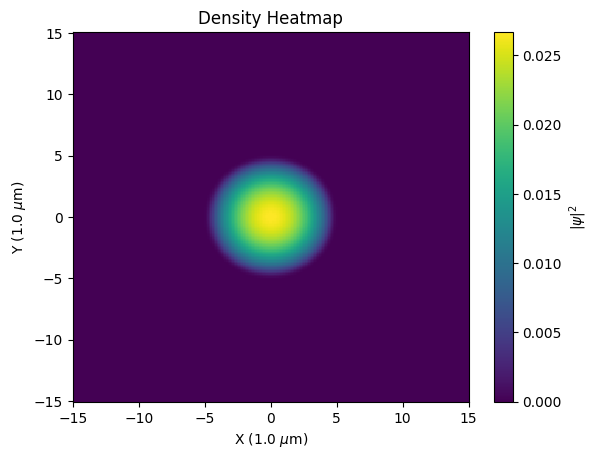

In [16]:
import matplotlib.pyplot as plt

plt.pcolormesh(bec.X, bec.Y, bec.density, shading='auto')
plt.colorbar(label=r'$|\psi|^2$')
plt.xlabel('X (' + str(bec.adim_length*1e6) + r' $\mu$m)')
plt.ylabel('Y (' + str(bec.adim_length*1e6) + r' $\mu$m)')
plt.title('Density Heatmap')
plt.show()

In [17]:
bec.density.size()

torch.Size([256, 256])

In [19]:
bec.density[128,:].size()

torch.Size([256])

In [21]:
bec.X.size()

torch.Size([256, 256])

TF radius R ≈ 4.89 µm
Chemical potential μ/h ≈ 16426.9 Hz


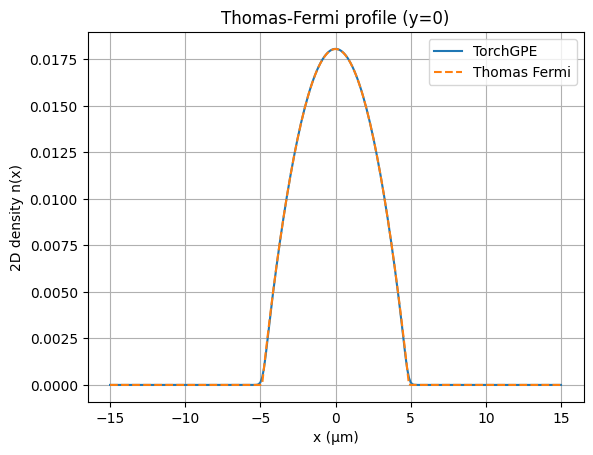

In [52]:
import numpy as np
plt.plot(bec.X[128,:], bec.density[128,:] / sum(bec.density[128,:]), label="TorchGPE")

# ----------------------------
# Constants
# ----------------------------
hbar = 1.054e-34
a0 = 5.29e-11
m = 1.443e-25        # Rb-87 mass (kg)

# ----------------------------
# Parameters
# ----------------------------
N = 2e5
omega = 2 * np.pi * 400      # x,y trap (Hz)
omega_z = 2 * np.pi * 116.25038809345646   # tight confinement (Hz)

a_s = 100 * a0               # scattering length

# ----------------------------
# Interaction strengths
# ----------------------------
g = 4 * np.pi * hbar**2 * a_s / m

a_z = np.sqrt(hbar / (m * omega_z))
g2D = g / (np.sqrt(2 * np.pi) * a_z)

# ----------------------------
# Chemical potential (2D TF)
# μ = sqrt( N g2D m ω^2 / π )
# ----------------------------
mu = np.sqrt(N * g2D * m * omega**2 / np.pi)

# ----------------------------
# TF radius
# ----------------------------
R = np.sqrt(2 * mu / (m * omega**2))

print(f"TF radius R ≈ {R*1e6:.2f} µm")
print(f"Chemical potential μ/h ≈ {mu/(6.626e-34):.1f} Hz")

# ----------------------------
# x grid
# ----------------------------
x = bec.X[128,:] * bec.adim_length

# ----------------------------
# Density profile (y = 0)
# ----------------------------
n = (mu - 0.5 * m * omega**2 * x**2) / g2D
n[n < 0] = 0

# ----------------------------
# Plot
# ----------------------------
plt.plot(x / bec.adim_length, n / sum(n), linestyle='dashed', label="Thomas Fermi")
plt.xlabel("x (µm)")
plt.ylabel("2D density n(x)")
plt.title("Thomas-Fermi profile (y=0)")
plt.grid()
plt.legend()
plt.show()

In [48]:
omega_z = 2 * np.pi * 116.25038809345646   # tight confinement (Hz)
a_z = np.sqrt(hbar / (m * omega_z))
print(a_z)
print(hbar / m / 1e-12 / 2 / np.pi)

1e-06
116.25038809345646
